In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'D:\Shorya\python\EDA Practice csv\day.csv')
df.sample(7)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
70,71,12-03-2018,1,0,3,0,6,0,1,13.495847,16.28750,59.4583,14.791925,724,1408,2132
381,382,17-01-2019,1,1,1,0,2,1,2,15.294763,18.21390,71.6087,23.391710,127,2808,2935
658,659,21-10-2019,4,1,10,0,0,0,1,19.030847,22.82145,51.0000,11.125618,2132,4692,6824
131,132,12-05-2018,2,0,5,0,4,1,1,21.935000,26.16815,74.7500,12.707689,695,4169,4864
322,323,19-11-2018,4,0,11,0,6,0,1,13.495847,16.22415,50.2083,15.041232,943,2720,3663
69,70,11-03-2018,1,0,3,0,5,1,2,12.977402,15.25000,64.9565,15.608990,247,1730,1977
153,154,03-06-2018,2,0,6,0,5,1,1,25.420000,29.35665,35.4167,16.959107,898,4414,5312


In [3]:
df.tail(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
720,721,22-12-2019,1,1,12,0,6,0,1,10.899153,11.80565,44.1250,27.292182,205,1544,1749
721,722,23-12-2019,1,1,12,0,0,0,1,10.079153,12.97355,51.5417,8.916561,408,1379,1787
722,723,24-12-2019,1,1,12,0,1,1,2,9.483464,12.94500,79.1304,5.174437,174,746,920
723,724,25-12-2019,1,1,12,1,2,0,2,11.943464,14.72325,73.4783,11.304642,440,573,1013
724,725,26-12-2019,1,1,12,0,3,1,3,9.976653,11.01665,82.3333,21.208582,9,432,441
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796
729,730,31-12-2019,1,1,12,0,1,1,2,8.849153,11.17435,57.7500,10.374682,439,2290,2729


In [4]:
df.shape

(730, 16)

In [5]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


#### NO duplicates or null values found

#### preparing data

In [10]:
df=df.drop(columns=['instant','dteday','casual','registered'],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    int64  
 1   yr          730 non-null    int64  
 2   mnth        730 non-null    int64  
 3   holiday     730 non-null    int64  
 4   weekday     730 non-null    int64  
 5   workingday  730 non-null    int64  
 6   weathersit  730 non-null    int64  
 7   temp        730 non-null    float64
 8   atemp       730 non-null    float64
 9   hum         730 non-null    float64
 10  windspeed   730 non-null    float64
 11  cnt         730 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 68.6 KB


### Preparing Features

In [12]:
X=df.drop(columns='cnt',axis=1)
y=df['cnt']

In [13]:
cat_cols=['season','yr','mnth','holiday','weekday','workingday','weathersit']
num_cols=['temp','atemp','hum','windspeed']

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop='first',sparse_output=False)
X_train_cat=encoder.fit_transform(X_train[cat_cols])
X_test_cat=encoder.transform(X_test[cat_cols])

### converting to dataframe

In [17]:
cat_feature_names = encoder.get_feature_names_out(cat_cols)
X_train_cat = pd.DataFrame(X_train_cat, columns=cat_feature_names, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=cat_feature_names, index=X_test.index)

#### combining with the original dataframe

In [19]:
X_train_final = pd.concat([X_train.drop(cat_cols, axis=1), X_train_cat], axis=1)
X_test_final = pd.concat([X_test.drop(cat_cols, axis=1), X_test_cat], axis=1)

#### Scaling numerical columns

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

In [22]:
X_train_num_scaled = pd.DataFrame(X_train_num_scaled,columns=num_cols, index=X_train.index)

X_test_num_scaled = pd.DataFrame(X_test_num_scaled,columns=num_cols,index=X_test.index)

#### combining scaled and encoded features

In [24]:
X_train = pd.concat([X_train_num_scaled, X_train_cat], axis=1)
X_test = pd.concat([X_test_num_scaled, X_test_cat], axis=1)

In [25]:
X_train

,temp,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
247,0.941813,0.896189,1.094484,0.352149,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
335,-1.029248,-0.922897,-0.063061,-1.144131,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
702,-0.142044,-0.072002,0.695937,-0.163360,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
440,0.068329,0.150533,0.851250,-1.011134,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
136,0.329003,0.357555,1.428559,1.216404,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-0.644103,-0.622050,-0.755419,1.126179,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106,-0.247225,-0.216421,-1.091660,1.565832,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
270,0.731446,0.584028,1.504750,-0.504207,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
435,-0.192346,-0.130504,-1.024254,0.285543,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [26]:
import statsmodels.api as sm
X_train_const=sm.add_constant(X_train)
base_model=sm.OLS(y_train,X_train_const).fit()
base_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     106.9
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          3.46e-203
Time:                        17:49:29   Log-Likelihood:                -4712.0
No. Observations:                 584   AIC:                             9482.
Df Residuals:                     555   BIC:                             9609.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2343.5142    188.071     12.461      0.000    1974.096    2712.932
temp           462.1882    480.649      0.962      0.337    -481.926    1406.302
atemp          387.6357    461.488      0.840      0.401    -518.842    1294.113
hum           -210.8580     47.650     -4.425      0.000    -304.455    -117.261
windspeed     -208.2759     37.778     -5.513      0.000    -282.481    -134.071
season_2      1099.0880    225.719      4.869      0.000     655.720    1542.456
season_3       999.7264    256.670      3.895      0.000     495.562    1503.891
season_4      1758.6827    222.105      7.918      0.000    1322.413    2194.952
yr_1          1970.7026     67.266     29.297      0.000    1838.576    2102.830
mnth_2         109.0414    165.056      0.661      0.509    -215.170     433.252
mnth_3         521.3079    203.996      2.555      0.011     120.609     922.007
mnth_4         167.0259    297.146      0.562      0.574    -416.643     750.694
mnth_5         432.0385    317.333      1.361      0.174    -191.281    1055.358
mnth_6         177.8401    333.979      0.532      0.595    -478.177     833.857
mnth_7        -217.2727    363.941     -0.597      0.551    -932.143     497.597
mnth_8          90.8545    355.044      0.256      0.798    -606.539     788.248
mnth_9         746.1279    312.550      2.387      0.017     132.203    1360.053
mnth_10        312.8788    282.908      1.106      0.269    -242.823     868.580
mnth_11       -392.3447    271.820     -1.443      0.149    -926.266     141.576
mnth_12       -272.5624    219.593     -1.241      0.215    -703.896     158.772
holiday_1     -239.8913    175.992     -1.363      0.173    -585.584     105.801
weekday_1     -109.6993     81.835     -1.340      0.181    -270.444      51.045
weekday_2      -30.8980     89.891     -0.344      0.731    -207.465     145.669
weekday_3       98.2988     90.474      1.086      0.278     -79.415     276.012
weekday_4       25.2984     87.604      0.289      0.773    -146.778     197.375
weekday_5      104.7457     89.912      1.165      0.245     -71.864     281.355
weekday_6      458.6162    121.653      3.770      0.000     219.659     697.574
workingday_1   327.6370     75.745      4.325      0.000     178.854     476.420
weathersit_2  -437.6205     88.427     -4.949      0.000    -611.314    -263.927
weathersit_3 -2098.8154    218.810     -9.592      0.000   -2528.613   -1669.018
==============================================================================
Omnibus:                       97.757   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              254.132
Skew:                          -0.846   Prob(JB):                     6.55e-56
Kurtosis:                       5.753   Cond. No.                     9.67e+15
===============

#### Selecting Significant features for next model

In [28]:
p_values = base_model.pvalues

# Keeping only significant features
significant_features = p_values[p_values < 0.05].index

In [29]:
significant_features = significant_features.drop('const', errors='ignore')
X_train_selected = X_train[significant_features]
X_train=X_train_selected

In [30]:
X_train_const=sm.add_constant(X_train)
Model1=sm.OLS(y_train,X_train_const).fit()
Model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     154.3
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          2.79e-170
Time:                        17:49:29   Log-Likelihood:                -4831.8
No. Observations:                 584   AIC:                             9690.
Df Residuals:                     571   BIC:                             9746.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1349.9489    130.254     10.364      0.000    1094.113    1605.785
hum            -72.4947     53.894     -1.345      0.179    -178.349      33.359
windspeed     -249.0584     43.074     -5.782      0.000    -333.662    -164.455
season_2      2507.6240    116.573     21.511      0.000    2278.660    2736.589
season_3      2831.5791    125.209     22.615      0.000    2585.653    3077.505
season_4      2254.1709    121.942     18.486      0.000    2014.661    2493.681
yr_1          2069.5000     80.308     25.769      0.000    1911.765    2227.235
mnth_3         435.1482    169.556      2.566      0.011     102.119     768.177
mnth_9         640.2450    154.235      4.151      0.000     337.308     943.182
weekday_6      502.1035    140.348      3.578      0.000     226.443     777.764
workingday_1   479.6372    105.662      4.539      0.000     272.104     687.170
weathersit_2  -621.7360    104.492     -5.950      0.000    -826.971    -416.501
weathersit_3 -2484.6352    255.898     -9.709      0.000   -2987.252   -1982.018
==============================================================================
Omnibus:                       50.993   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              100.071
Skew:                          -0.534   Prob(JB):                     1.86e-22
Kurtosis:                       4.724   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [31]:
X_train.columns

Index(['hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'yr_1',
       'mnth_3', 'mnth_9', 'weekday_6', 'workingday_1', 'weathersit_2',
       'weathersit_3'],
      dtype='object')

In [32]:
X_train=X_train.drop(columns='hum',axis=1)

In [33]:
X_train_const1=sm.add_constant(X_train)
Model2=sm.OLS(y_train,X_train_const1).fit()
Model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     167.9
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          5.16e-171
Time:                        17:49:29   Log-Likelihood:                -4832.7
No. Observations:                 584   AIC:                             9689.
Df Residuals:                     572   BIC:                             9742.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1389.0898    127.053     10.933      0.000    1139.543    1638.636
windspeed     -232.3514     41.274     -5.630      0.000    -313.418    -151.285
season_2      2491.0035    115.998     21.474      0.000    2263.169    2718.838
season_3      2816.7774    124.812     22.568      0.000    2571.631    3061.924
season_4      2229.2544    120.612     18.483      0.000    1992.357    2466.152
yr_1          2083.0831     79.727     26.128      0.000    1926.490    2239.677
mnth_3         449.0702    169.359      2.652      0.008     116.429     781.712
mnth_9         611.4874    152.854      4.000      0.000     311.263     911.711
weekday_6      507.4245    140.391      3.614      0.000     231.680     783.169
workingday_1   482.5284    105.714      4.564      0.000     274.893     690.164
weathersit_2  -703.1077     85.261     -8.247      0.000    -870.570    -535.646
weathersit_3 -2632.2574    231.334    -11.379      0.000   -3086.626   -2177.889
==============================================================================
Omnibus:                       49.759   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               95.329
Skew:                          -0.530   Prob(JB):                     1.99e-21
Kurtosis:                       4.671   Cond. No.                         8.66
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### checking Residuals

In [35]:
sns.set_style()
sns.set_theme(style='darkgrid')

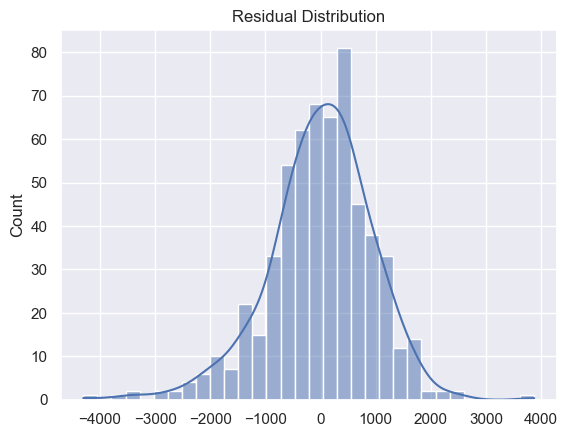

In [36]:
residuals = Model2.resid

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

#### Residuals vs Fitted values

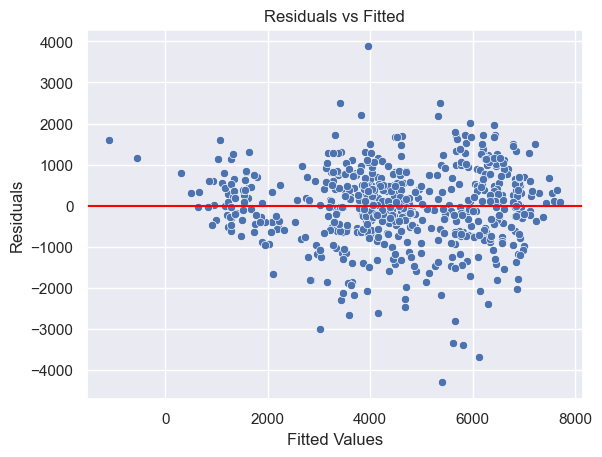

In [38]:
sns.scatterplot(x=Model2.fittedvalues, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#### Q-Q Plot

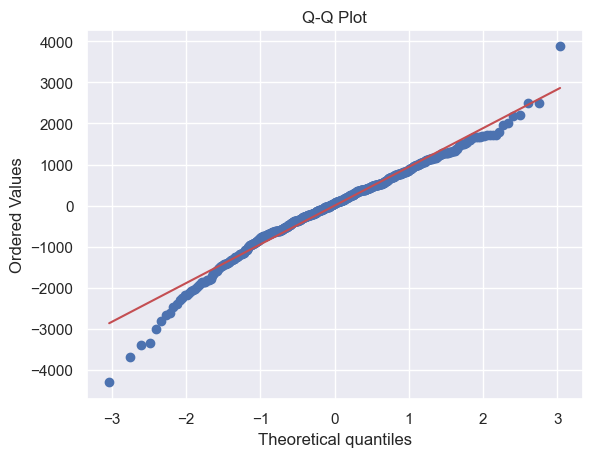

In [40]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

### Fitting Linear regression model

### Predictions

In [73]:
X_test_selected = X_test[significant_features]

X_test=X_test_selected
X_test=X_test.drop(columns='hum',axis=1)

In [75]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [77]:
y_pred = lr.predict(X_test)

#### Model Evaluation

In [82]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.7706061079490777
MSE: 785179.0409374869


#### Comparing predictions with actual results

In [93]:
import numpy as np
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Absolute Error
results_df['Absolute_Error'] = np.abs(results_df['Actual'] - results_df['Predicted'])
results_df.head(15)

,Actual,Predicted,Absolute_Error
468,7460,6456.418571,1003.581429
148,4788,3794.413729,993.586271
302,3331,3648.573892,317.573892
355,3068,1600.442712,1467.557288
515,7338,6417.975221,920.024779
266,5423,4369.466310,1053.533690
72,2046,2474.187998,428.187998
81,2121,3959.786651,1838.786651
133,3409,3844.046637,435.046637
342,3620,4422.732119,802.732119


#### The comparison between actual and predicted values shows that the model performs reasonably well overall, with many predictions close to the true values. However, there are some instances with larger errors (e.g., 1000+), indicating that the model struggles in certain cases—especially where demand patterns may be more complex or influenced by factors not captured in the model. Overall, the error distribution suggests that while the model captures general trends effectively, it has limitations in handling extreme or less frequent scenarios.

In [88]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})

coef_df

,Feature,Coefficient
0,windspeed,-232.351394
1,season_2,2491.003507
2,season_3,2816.777425
3,season_4,2229.254373
4,yr_1,2083.083131
5,mnth_3,449.070207
6,mnth_9,611.487381
7,weekday_6,507.424487
8,workingday_1,482.528372
9,weathersit_2,-703.107716


#### The coefficients derived from the linear regression model demonstrate high alignment with those of the baseline OLS model. This consistency across iterations validates the structural stability of the model and confirms that the estimated relationships are robust rather than artifacts of a specific estimation method.

## Project Summary

This project focused on building a regression model to predict bike rental demand using the Bike Sharing dataset. The workflow began with data preprocessing, including handling date variables, extracting relevant features such as month, and identifying categorical and numerical variables. Categorical features were transformed using one-hot encoding to make them suitable for modeling, while numerical features were scaled to ensure uniformity and improve model stability. The dataset was then split into training and testing sets to ensure unbiased evaluation.

An initial Ordinary Least Squares (OLS) regression model was developed to understand relationships between features and the target variable. This step was crucial for statistical interpretation, as it provided insights into feature significance through p-values. Based on this, non-significant variables were iteratively removed to refine the model and reduce noise. Multicollinearity was also addressed, resulting in a stable model with a low condition number. Residual diagnostics were performed to validate assumptions such as normality and homoscedasticity, ensuring the model was statistically sound.

After establishing a reliable OLS model, a Linear Regression model using sklearn was built using the selected important features. This step focused on predictive performance rather than statistical inference. The model achieved a solid R² score (~0.76), indicating that it could explain a substantial portion of the variance in bike demand. The evaluation using absolute error further confirmed that the model performs well for most observations, though some larger errors remain for specific cases.

The model is satisfactory because it balances interpretability and performance. It successfully identifies key drivers of demand such as seasonality, weather conditions, and temporal patterns (e.g., weekends and working days). Additionally, issues like multicollinearity were resolved, and residuals, while not perfectly normal, are acceptable for practical applications. The model is stable, interpretable, and aligned with real-world expectations.

However, the model does have some limitations. Residual analysis revealed mild heteroscedasticity and slight skewness, indicating that the model does not fully capture all underlying patterns. Additionally, the presence of larger prediction errors suggests that certain non-linear relationships or interaction effects are not modeled. The linear assumption itself may restrict the model’s ability to adapt to more complex patterns in the data.

There is scope for further improvement. Techniques such as adding interaction terms, introducing non-linear transformations, or using more advanced models like Ridge, Lasso, or tree-based methods (e.g., Random Forest) could enhance performance. Additionally, incorporating more contextual features, such as holidays or external factors, may help reduce prediction errors in edge cases.

In conclusion, the final model provides a strong and reliable baseline for predicting bike rental demand. It demonstrates a well-structured approach to data preprocessing, feature selection, and model evaluation. While not perfect, it achieves a good balance between simplicity, interpretability, and predictive power, making it a solid foundation for further enhancements and real-world applications.

